# 6 #
In this exercise, you will further analyze the Wage data set considered
throughout this chapter.

(a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.

In [89]:
import numpy as np
import pandas as pd
from ISLP import load_data
from ISLP.models import (summarize,
                         ModelSpec,
                         poly)
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.stats.anova import anova_lm
from statsmodels.api import OLS
from matplotlib.pyplot import subplots

Wage =  load_data('Wage')
Wage.head(3)

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177


In [90]:
X_age = Wage[['age']]
y = Wage['wage'] 

In [100]:
pipe_age_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
grid_poly = {'poly__degree': range(0,6)}

linear_poly_cv = GridSearchCV(pipe_age_poly, grid_poly, cv=5, scoring='neg_mean_squared_error')
linear_poly_cv.fit(X_age, y)
linear_poly_cv.best_params_

{'poly__degree': 4}

In [101]:
pd.DataFrame(linear_poly_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_poly__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005601,0.001424,0.002048,0.000705,0,{'poly__degree': 0},-1938.282682,-1630.420540,-1586.901932,-1739.892246,-1811.178750,-1741.335230,126.348890,6
1,0.003799,0.000231,0.001631,0.000283,1,{'poly__degree': 1},-1878.151560,-1568.713243,-1526.157551,-1681.168895,-1720.879941,-1675.014238,123.987523,5
2,0.003956,0.000615,0.001655,0.000247,2,{'poly__degree': 2},-1763.238962,-1489.123713,-1459.204994,-1621.776055,-1664.647410,-1599.598227,112.620087,4
3,0.004464,0.000799,0.001753,0.000337,3,{'poly__degree': 3},-1759.055177,-1487.270483,-1448.413468,-1616.951224,-1661.940729,-1594.726216,113.991143,2
4,0.004468,0.000741,0.001572,0.000289,4,{'poly__degree': 4},-1760.319050,-1494.086167,-1446.532118,-1611.428666,-1657.204518,-1593.914104,112.862845,1
5,0.003458,0.000289,0.001549,0.000396,5,{'poly__degree': 5},-1759.309580,-1504.745664,-1446.521378,-1610.118476,-1656.470557,-1595.433131,110.630596,3


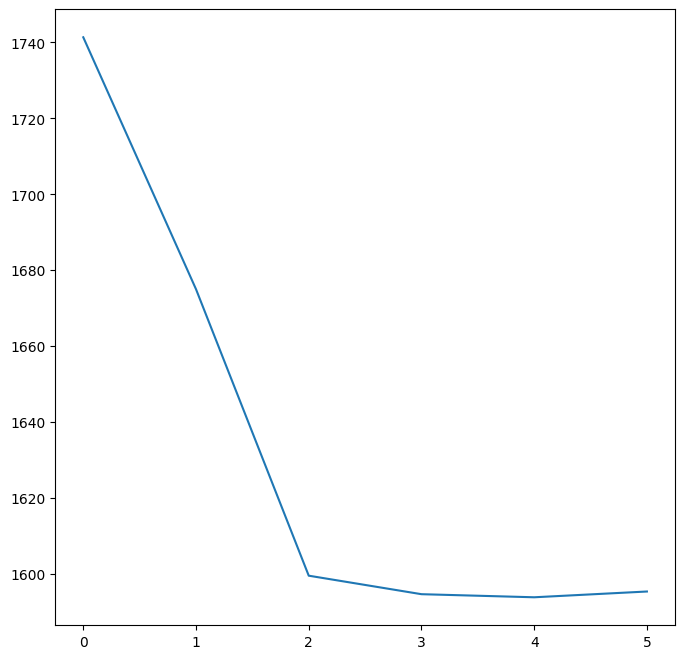

In [102]:
ax = subplots(figsize=(8,8))[1]
ax.plot(linear_poly_cv.cv_results_['param_poly__degree'], -linear_poly_cv.cv_results_['mean_test_score'])

In [103]:
predicoes = linear_poly_cv.predict(X_age)
print('RSS melhor modelo grid cv :',np.sum((predicoes - y)**2))

RSS melhor modelo grid cv : 4771604.24882639


In [104]:
models = [ModelSpec([poly('age', degree=d)]) for d in range(1,6)]
Xs = [model.fit_transform(Wage) for model in models]
anova_lm (*[OLS(y,X_).fit() for  X_ in Xs])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0,5.022216e+06,0.0,NaN,NaN,NaN
1,2997.0,4.793430e+06,1.0,228786.010128,143.593107,2.363850e-32
2,2996.0,4.777674e+06,1.0,15755.693664,9.888756,1.679202e-03
3,2995.0,4.771604e+06,1.0,6070.152124,3.809813,5.104620e-02
4,2994.0,4.770322e+06,1.0,1282.563017,0.804976,3.696820e-01


Text(0.5, 1.0, "Age x Wage {'poly__degree': 4}")

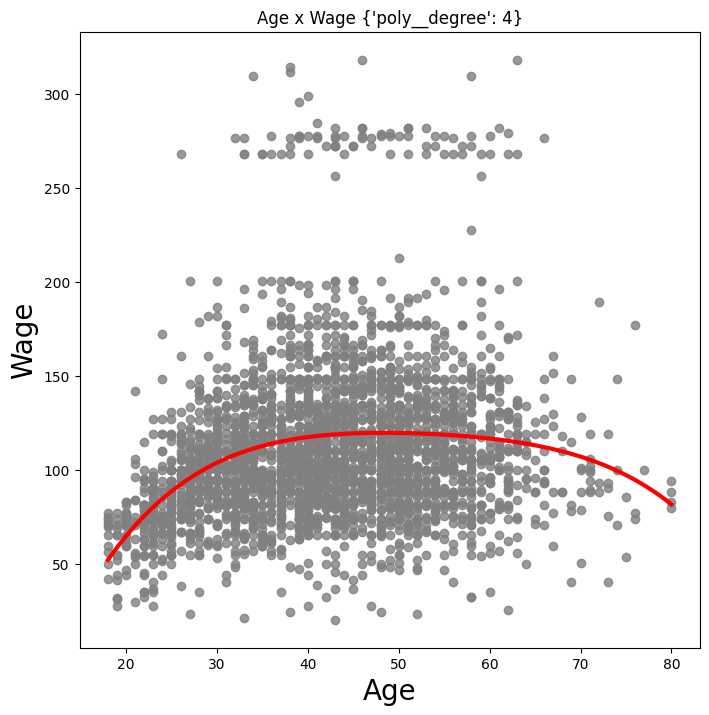

In [109]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(X_age, y, facecolor='gray', alpha=0.8)
lin_idade_min_max = pd.DataFrame({'age':np.linspace(X_age.age.min(),X_age.age.max(), 100)})
ax.plot(lin_idade_min_max, linear_poly_cv.predict(lin_idade_min_max), '-r', linewidth=3)
ax.set_xlabel('Age', fontsize=20)
ax.set_ylabel('Wage', fontsize=20)
ax.set_title(f'Age x Wage {linear_poly_cv.best_params_}')

In [155]:
from sklearn.preprocessing import KBinsDiscretizer

pipe_age_kbins = Pipeline([
    ('discretizer', KBinsDiscretizer(quantile_method='averaged_inverted_cdf',n_bins=2, encode='onehot')),
    ('linear', LinearRegression())
])
grid_kbins = [{'discretizer__n_bins': range(2,11),
               'discretizer__strategy': ['quantile']},
              
              {'discretizer__n_bins': range(2,21),
              'discretizer__strategy': ['uniform', 'kmeans']}
              ]

linear_kbins_cv = GridSearchCV(pipe_age_kbins,
             grid_kbins,
             cv=5,
             scoring='neg_mean_squared_error')
linear_kbins_cv.fit(X_age,y)
linear_kbins_cv.best_params_

{'discretizer__n_bins': 13, 'discretizer__strategy': 'kmeans'}

In [152]:
pd.DataFrame(linear_kbins_cv.cv_results_).sort_values(by='mean_test_score',ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_discretizer__n_bins,param_discretizer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
32,0.007320,0.001130,0.002124,0.000362,13,kmeans,"{'discretizer__n_bins': 13, 'discretizer__stra...",-1761.867356,-1520.806284,-1457.600490,-1612.205217,-1644.149938,-1599.325857,104.734157,1
38,0.007430,0.000962,0.002085,0.000705,16,kmeans,"{'discretizer__n_bins': 16, 'discretizer__stra...",-1753.082566,-1529.477461,-1452.747641,-1609.172735,-1652.226177,-1599.341316,102.859614,2
37,0.006358,0.001331,0.001797,0.000145,16,uniform,"{'discretizer__n_bins': 16, 'discretizer__stra...",-1754.077350,-1529.477461,-1453.098651,-1609.032775,-1654.459778,-1600.029203,103.286707,3
31,0.004926,0.000472,0.002031,0.000502,13,uniform,"{'discretizer__n_bins': 13, 'discretizer__stra...",-1761.934456,-1524.838830,-1457.600490,-1615.030173,-1648.092019,-1601.499194,104.572559,4
21,0.005411,0.000953,0.002021,0.000156,8,uniform,"{'discretizer__n_bins': 8, 'discretizer__strat...",-1761.459879,-1527.176201,-1457.934475,-1610.577474,-1656.072716,-1602.644149,104.667365,5
27,0.008574,0.002083,0.004322,0.001192,11,uniform,"{'discretizer__n_bins': 11, 'discretizer__stra...",-1758.825483,-1539.541699,-1461.281624,-1609.472713,-1655.698617,-1604.964027,101.185363,6
30,0.007257,0.000689,0.002352,0.000608,12,kmeans,"{'discretizer__n_bins': 12, 'discretizer__stra...",-1766.784499,-1540.956998,-1456.089816,-1609.247956,-1654.122235,-1605.440301,104.766448,7
29,0.005980,0.001140,0.001850,0.000252,12,uniform,"{'discretizer__n_bins': 12, 'discretizer__stra...",-1766.507228,-1541.312715,-1457.352594,-1610.105819,-1655.039674,-1606.063606,104.369338,8
42,0.007823,0.000999,0.002217,0.000446,18,kmeans,"{'discretizer__n_bins': 18, 'discretizer__stra...",-1759.900397,-1541.959860,-1450.390935,-1626.806718,-1654.495277,-1606.710637,104.673625,9
41,0.007062,0.000652,0.002366,0.000538,18,uniform,"{'discretizer__n_bins': 18, 'discretizer__stra...",-1760.584135,-1544.077242,-1452.529106,-1620.891282,-1658.677392,-1607.351832,104.183990,10


In [147]:
bilada = pd.DataFrame(linear_kbins_cv.cv_results_).sort_values(by='mean_test_score',ascending=False).groupby('param_discretizer__strategy')
for s, df in bilada:
    print(df.head(2))
    print('diaxo de scalar', s)

    mean_fit_time  std_fit_time  ...  std_test_score  rank_test_score
31       0.007219      0.001104  ...      104.734157                1
37       0.006962      0.001093  ...      102.859614                2

[2 rows x 15 columns]
diaxo de scalar kmeans
   mean_fit_time  std_fit_time  ...  std_test_score  rank_test_score
7       0.004749      0.000950  ...      111.294311               29
5       0.004715      0.000887  ...      112.650120               30

[2 rows x 15 columns]
diaxo de scalar quantile
    mean_fit_time  std_fit_time  ...  std_test_score  rank_test_score
36       0.006390      0.001100  ...      103.286707                3
30       0.006055      0.001131  ...      104.572559                4

[2 rows x 15 columns]
diaxo de scalar uniform


Text(0.5, 1.0, "Age x Wage {'discretizer__n_bins': 13, 'discretizer__strategy': 'kmeans'}")

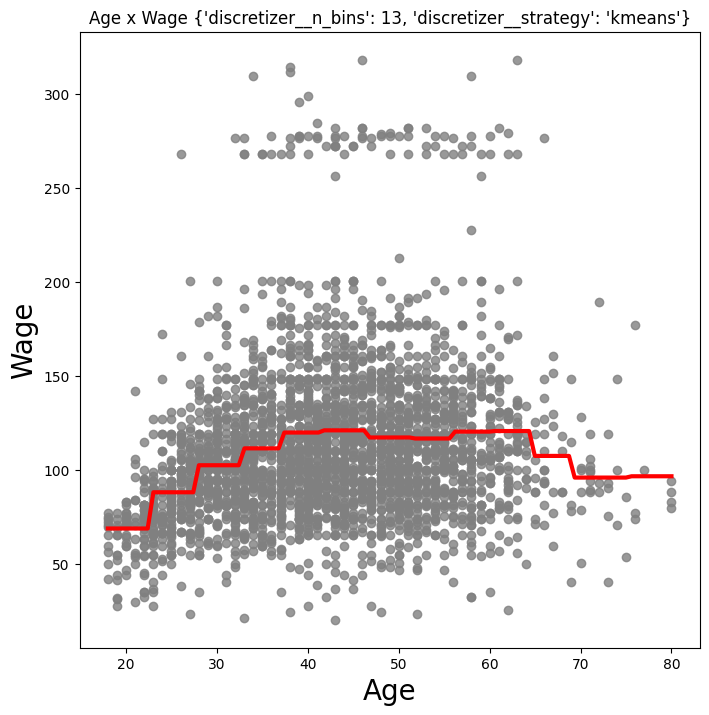

In [153]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(X_age, y, facecolor='gray', alpha=0.8)
ax.plot(lin_idade_min_max, linear_kbins_cv.predict(lin_idade_min_max), '-r', linewidth=3)
ax.set_xlabel('Age', fontsize=20)
ax.set_ylabel('Wage', fontsize=20)
ax.set_title(f'Age x Wage {linear_kbins_cv.best_params_}')